In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

# Problem 1

## Part A
We initialize a random matrix A and vector b from a uniform distribution, and then solve the basis pursuit problem
in CVXPY.

In [3]:
np.random.seed(0)

N = 10
shape = (N, 2 * N)

A = np.random.uniform(0, 1, shape)
b = np.random.uniform(0, 1, shape[0])

In [4]:
x_bp = cp.Variable(A.shape[1])
objective = cp.Minimize(cp.norm(x_bp, p=1))
constraints = [A @ x_bp == b]
prob = cp.Problem(objective, constraints)
result_cvx = prob.solve()
print(f"L1 norm of solution: {objective.value}")
print(f"L2 norm of Ax-b: {np.linalg.norm(A @ x_bp.value - b)}")


L1 norm of solution: 2.5553184970183893
L2 norm of Ax-b: 1.5826015279554355e-14


## Part b
We now use the proximal gradient descent method from the previous homework to solve the corresponding
least squares problem, using the tau computed the previous part. The projection onto the L1 norm is incorporated
through an indicator cost function over the set of all `x` with L1 norm less than tau.

In [5]:
from cvx_opt.hw6 import prox_gradient_descent
from cvx_opt.hw10 import project_l1
from typing import Union

In [6]:
class Operator:
    def __init__(self, forward, adjoint, input_shape):
        self.forward = forward
        self.adjoint = adjoint
        self.input_shape = input_shape

    def __call__(self, x):
        return self.forward(x)

    @classmethod
    def from_matrix(cls, A):
        assert isinstance(A, np.ndarray), "A must be an array"
        assert A.ndim == 2, "Matrix must be 2D"
        forward = lambda x: A @ x
        adjoint = lambda y: A.T @ y
        input_shape = A.shape[1]
        return cls(forward, adjoint, input_shape)
        
class LeastSquaresCost:
    def __init__(self, A: Operator, b: np.ndarray):
        self.A = A
        self.b = b
        
    def f(self, x):
        return 1/2 * np.sum(
            (self.A(x) - b)**2
        )

    def grad(self, x):
        return self.A.adjoint(self.A(x) - b)


EPS = 1e-14

class L1Indicator:
    def __init__(self, tau):
        self.tau = tau

    def g(self, x):
        return 0
        # The project_l1 function returns points that are just slightly infeasible,
        # i.e. with 0 < ||x||_1 - tau < 1e-15. Add a small epsilon so that these points
        # are not assigned infinite cost.
        if np.linalg.norm(x, ord=1) > self.tau + EPS:
            return np.inf
        else:
            return 0


    def prox(self, t, x):
        return project_l1(x, self.tau)

In [7]:
def ls_tau(A: Union[Operator, np.ndarray], b: np.ndarray, tau: float, x0: np.ndarray = None, **kwargs):
    
    if isinstance(A, np.ndarray):
        A = Operator.from_matrix(A)
        
    if x0 is None:
        x0 = np.zeros(A.input_shape)
        
    f = LeastSquaresCost(A, b)
    g = L1Indicator(tau)
    return prox_gradient_descent(f, x0, g, full_history=False, **kwargs)

So the proximal descent solution has a slightly larger L2 norm of Ax - b compared with cvxpy (1e-11 vs 1e-14), and the L1 norm is essentially within machine precision of the cvxpy basis pursuit solution.  The L2 norm of could be reduced by running the algorithm for additional iterations.

In [8]:
tau = result_cvx
prox_result = ls_tau(A, b, tau, tol=1e-8)
print(prox_result)
print(f"L2 norm of Ax - b {prox_result.costs[-1]}")
print(f"Distance between cvxpy basis pursuit solution and solution by proximal descent: {
    np.linalg.norm(x_bp.value - prox_result.solution)
}")
print(f"Feasibility: ||x||_1 - tau = {
    np.linalg.norm(prox_result.solution, ord=1) - tau
}")

SolverResult:
    Converged=False
    iterations=100000
    function_eval=4.130274238532891e-10

L2 norm of Ax - b 4.130274238532891e-10
Distance between cvxpy basis pursuit solution and solution by proximal descent: 0.0007293964474414494
Feasibility: ||x||_1 - tau = 1.3322676295501878e-15


From the convergence plot below, it appears the convergence rate of the solver in this case runs even a bit faster than the theoretical O(1/k^2) bound.

Text(0.5, 1.0, 'L2 norm of A x_k - b over iteration')

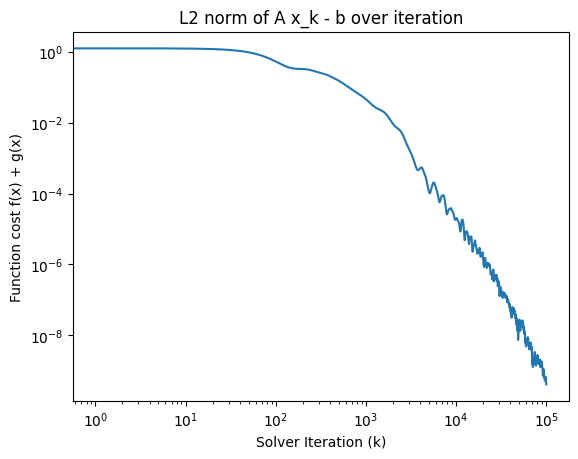

In [9]:
prox_result.plot(loglog=True)
plt.title("L2 norm of A x_k - b over iteration")

# Problem 2

In [10]:
from cvx_opt.hw10 import BasisPursuitResult

In [11]:
def subproblem(A, b, tau, x0, **kwargs):
    result = ls_tau(A, b, tau, x0=x0, **kwargs)
    x0 = result.solution
    nu = A(x0) - b
    # nu /= np.linalg.norm(nu)
    lambda_ = np.linalg.norm(A.adjoint(nu), ord=np.inf)
    sigma = result.costs[-1]
    d_sigma = -lambda_
    return result, sigma, d_sigma
    
    
    
def basis_pursuit(A, b, tau0=0.1, subproblem_kwargs=None, tol_tau=1e-6, maxiters=100):
    if isinstance(A, np.ndarray):
        A = Operator.from_matrix(A)

    if subproblem_kwargs is None:
        subproblem_kwargs = {'tol': 1e-11, 'stepsize': 1e-4}
        
    tau = np.zeros(maxiters + 1, dtype=float)
    sigma = np.zeros(maxiters + 1, dtype=float)
    d_sigma = np.zeros(maxiters + 1, dtype=float)
    sub_results = []
    
    tau[0] = tau0
    x0 = None
    converged = False
    
    for k in range(maxiters):
        print(f"k = {k}")
        result, sigma[k], d_sigma[k] = subproblem(A, b, tau[k], x0, **subproblem_kwargs)
        x0 = result.solution
        sub_results.append(result)
        
        tau[k+1] = tau[k] - sigma[k] / d_sigma[k]
        if abs(tau[k+1] - tau[k]) < tol_tau:
            converged = True
            break
        # if np.isclose(abs(sigma[k] - sigma[k-1]), 0):
        #     converged=False
        #     break
    
    result, sigma[k+1], d_sigma[k+1] = subproblem(A, b, tau[k+1], x0, **subproblem_kwargs)
    sub_results.append(result)
    
    return BasisPursuitResult(
        tau[:k+2], sigma[:k+2], d_sigma[:k+2], converged, sub_results)

In [12]:
result_bp = basis_pursuit(A, b, subproblem_kwargs={'tol': 1e-11, 'stepsize':1e-5}, tol_tau=1e-4)

k = 0
k = 1
k = 2
k = 3
k = 4
k = 5
k = 6
k = 7
k = 8
k = 9
k = 10
k = 11
k = 12
k = 13
k = 14
k = 15
k = 16
k = 17


In [13]:
print(result_bp)
print("Distance from CVXPY's tau", result_bp.tau[-1] - tau)

BasicPursuitResult(
    Converged=True
    Iterations=19
)
Distance from CVXPY's tau -6.794634133289179e-05


Our algorithm converges to the same result as CVXPY, within our perscribed tolerance of 1e-4. Interestingly, while Newton's method often has quadratic convergence, the convergence here is simply linear. This is since the derivative $d\sigma/d\tau$ also approaches 0 as $\tau \to \tau_{bp}$. The basic pursuit solution $\tau_{bp}$ is a root of $\sigma(\tau)$ with multiplicity 2.

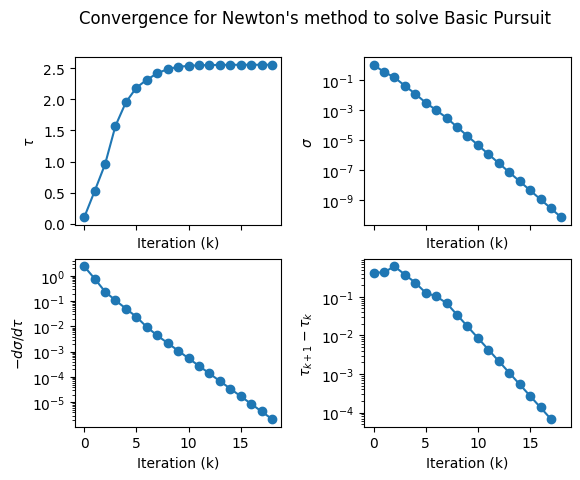

In [14]:
result_bp.plot_convergence()

# Problem 3

NOTE: audio files can be played by downloading an HTML-exported version of this notebook, available [here](https://github.com/seanjennings960/study-hard/blob/main/cvx-opt/notebooks/hw10.html) on Github.

In [15]:
from cvx_opt.hw10 import load_audio, forwardShortTimeDCT, adjointShortTimeDCT
from IPython.display import Audio

In [16]:
y, Fs = load_audio()

In [17]:
Audio(y, rate=Fs)

In [18]:
# Run the M-DCT once on the original signal to initialize the window, etc.
coeff, win = forwardShortTimeDCT(y)
N_true = y.shape[0]

In [19]:
D = lambda x: forwardShortTimeDCT(x, win)
Dt = lambda y: adjointShortTimeDCT(y, win, N_true)

In [20]:
# Test that adjointDCT is the inverse forwardDCT.
y2 = adjointShortTimeDCT(coeff, win, N_true)
assert np.isclose(np.linalg.norm(y - y2), 0)
assert np.isclose(np.linalg.norm(Dt(D(y)) - y), 0)

The code below creates the downsample function $\Psi$ and its adjoint $\Psi^T$, the upsampling function. Since we are sampling randomly, we can't do any better than just replacing the unknown samples with zeros. This can't be good for sound quality... We'll fix this later, but first we'll show that the problem formulation with $A = \Psi D^T$ and $b = \Psi y$ doesn't solve (the author's interpretation of) the downsampling problem.

In [21]:
def sample_functions(N, frac):
    
    np.random.seed(100)

    num_samples = int(N * frac)
    indices = np.random.permutation(N)[:num_samples]
    
    def downsample(y):
        assert y.shape[0] == N
        return y[indices]

    def upsample(x):
        y = np.zeros(N, dtype=float)
        y[indices] = x
        return y

    return downsample, upsample

In [22]:
def test_sampling_functions():
    N = 200
    frac = 0.25
    N_down = int(N * frac)
    y = np.arange(N)
    
    psi, psi_t = sample_functions(N, 0.25)
    
    xs = [np.ones(N_down), np.random.randint(0, 10, N_down)]
    for x in xs:
        assert np.isclose(np.dot(psi(y), x), np.dot(y, psi_t(x)))

# Make sure that upsample and downsample truely are adjoints.
test_sampling_functions()

In [ ]:
# And now we initialize the problem as formulated in the homework.
subproblem_kwargs = {'tol': 1e-4, 'stepsize': 1e-3}
downsample_rate = 0.25
psi, psi_t = sample_functions(y.shape[0], downsample_rate)

A = Operator(
    forward=lambda x: psi(Dt(x)),
    adjoint=lambda y: D(psi_t(y)),
    input_shape=coeff.shape)
b = psi(y)
handel_result1 = basis_pursuit(A, b, subproblem_kwargs=subproblem_kwargs, tol_tau=1e0)

## Analysis of the data

The first thing to note is that are convergence check on tau is not sufficient in all cases. Depending on the requested
tolerance for $\tau$ and the tolerance for the proximal gradient subproblem, the iteration may fail to converge. Both $\sigma$ and $d\sigma / d\tau$ settle around some lower bound, presumably dependent on the subproblem error $\tilde{x}_\tau = \hat{x}_\tau + x_\tau$. The algorithm continues to solve for higher $\tau$ until the maximum number of iterations is reached.


(0.0, 30.0)

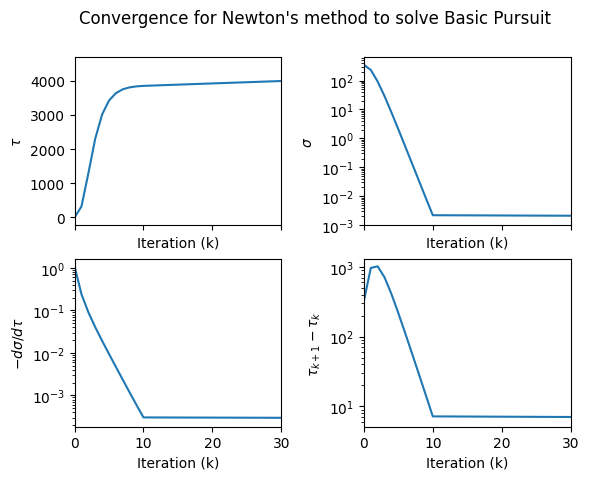

In [26]:
handel_result1.plot_convergence(fmt='-')
plt.xlim([0, 30])

Van den Berg and Friedlander suggest decreasing the subproblem tolerance as the number of steps continues, but for now we satisfy ourselves with simply slicing the result manually.

In [27]:
handel_result1 = handel_result1[:11]

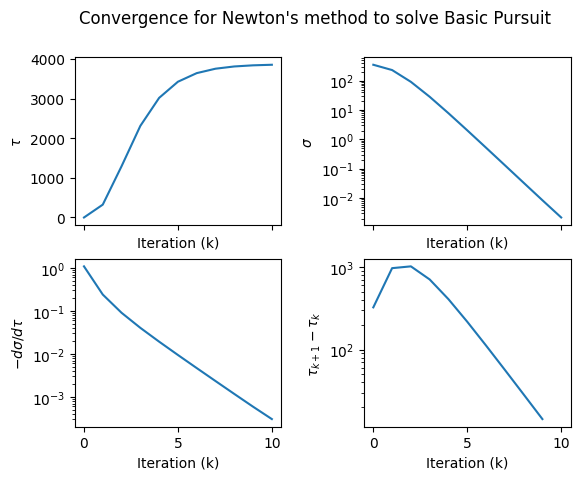

In [29]:
handel_result1.plot_convergence(fmt='-')
# plt.xlim([0, 10])

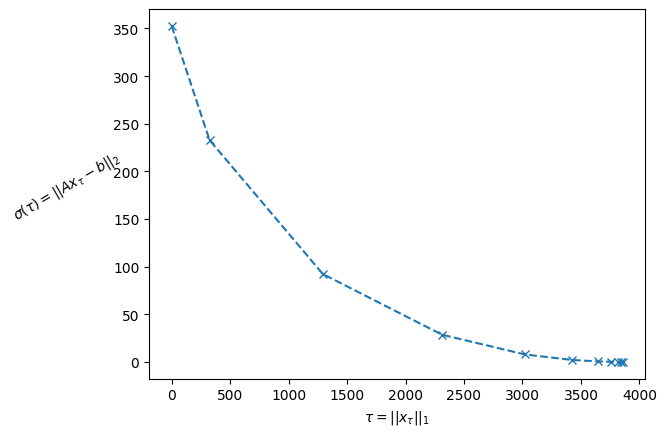

In [31]:
handel_result1.plot_pareto_frontier()

## Spectrum of Original and Approximate Audio Clips

Let's look at a spectrogram of the signals to try to identify any differences.

In [32]:
import scipy.signal as sig

In [33]:
def mag2db(x):
    return 20 * np.log10(np.abs(x))

In [34]:
def plot_spectrogram(y, Fs):
    plt.figure(figsize=(12, 12))
    f, t, Sxx = sig.spectrogram(y, fs=Fs, window='barthann', nperseg=512, scaling='density')
    plt.pcolormesh(f, t, 1/2 * mag2db(Sxx.T), vmin=-50, vmax=-30)
    # plt.pcolormesh(f, t, 1/2 * mag2db(Sxx.T))
    plt.colorbar()
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Time [sec]")


Text(0.5, 1.0, 'Spectrogram of original signal')

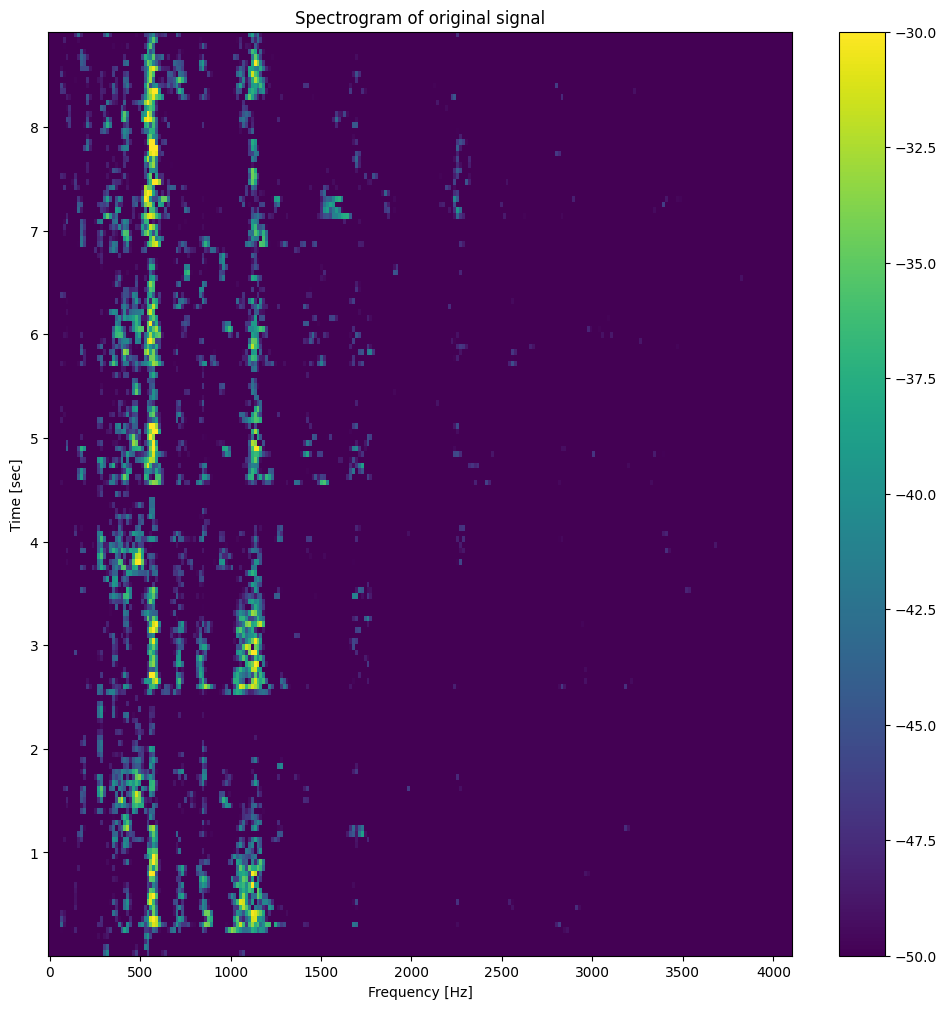

In [35]:
plot_spectrogram(y, Fs)
plt.title("Spectrogram of original signal")

Text(0.5, 1.0, 'Spectrogram of Basis Pursuit Approximation')

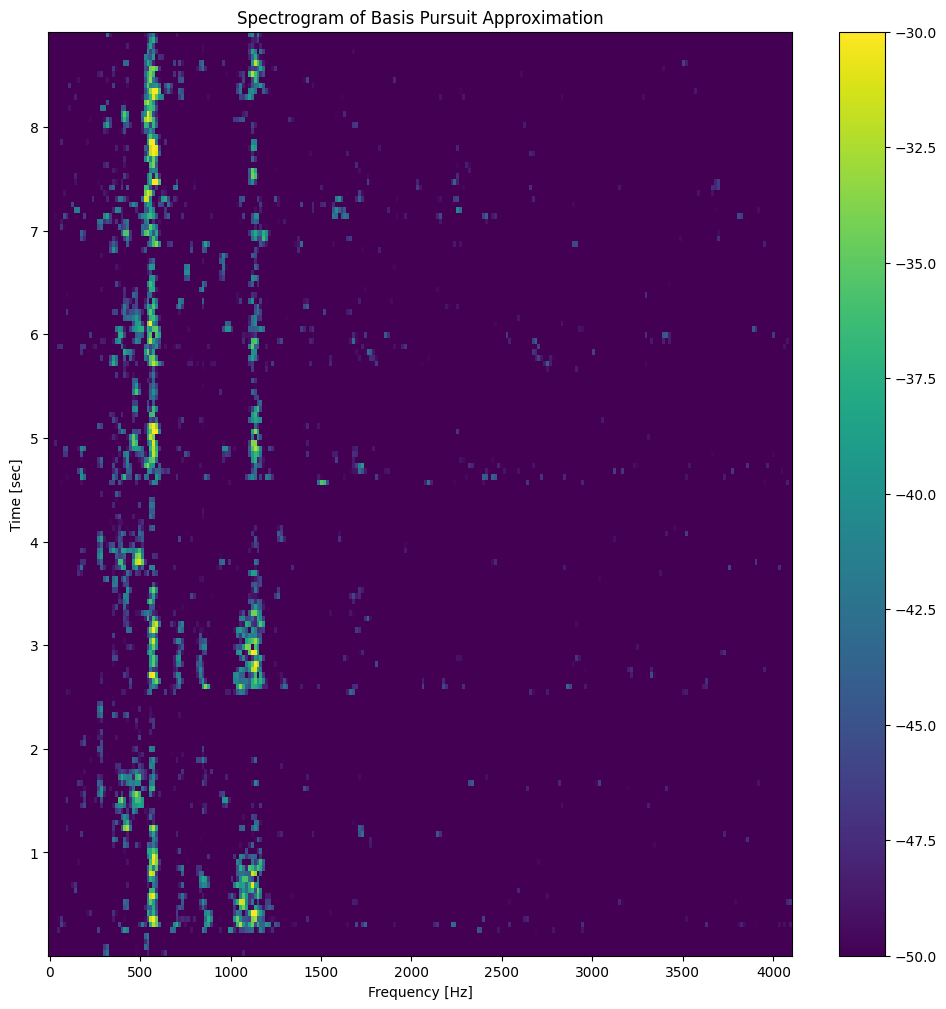

In [38]:
y_out = Dt(handel_result1.bp_solution)
plot_spectrogram(y_out, Fs)
plt.title("Spectrogram of Basis Pursuit Approximation")

Hard to tell super precisely, but let's look at the spectrogram of the error:

Text(0.5, 1.0, 'Spectrum of error between original and approximation')

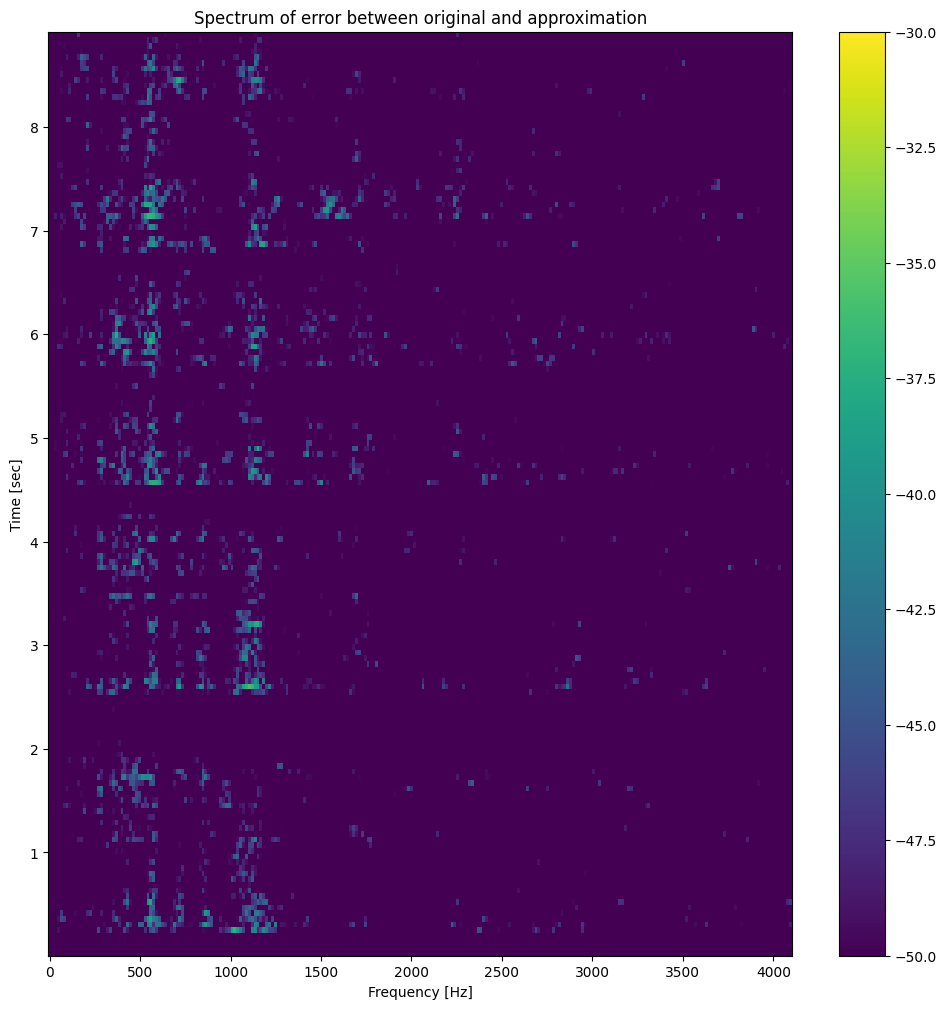

In [39]:
plot_spectrogram(y_out - y, Fs)
plt.title("Spectrum of error between original and approximation")

We will use average signal power of the residual norm $||\hat{y} - y||_2$ (in the signal processing sense) to measure the "quality" of the approximation. We'll call this the quality error of our compressed signal approximation.

The average power in a continuous signal $x(t)$ over time interval $[0, T]$ is given by:

$P(x) = \frac{1}{T} \int_0^T |x(\tau)|^2 d\tau$

The power can be approximated from a discrete sampling $x_i$ for each $i\in 1,\dots, N$ where $N$ is the number of samples, and is related to the sampling timestep $\Delta$ by $N = T / \Delta$.

Taking a Riemann approximation of the above integral yields the average power of the discretized signal:

$P(x) = \frac{1}{N} \sum_{i=0}^N x_i^2 = \frac{1}{N} ||x||_2^2$ 

In [40]:
def power(x, axis=None):
    if axis is None:
        ell = len(x)
    else:
        ell = x.shape[axis]
    return np.linalg.norm(x, axis=axis)**2 / ell

We now compare the magnitude of the error both the full and downsampled signals. We see that error on the
downsampled signal is very small, which is expected since it is exactly the quantity we optimized. However, the error of the signal on
the full time domain is large. In fact, it is comparable in magnitude to the signal itself!

In [41]:
# Error in the signal:
power_error = power(y - y_out)
power_error_downsampled = power(psi(y - y_out))
print(f"Average error in signal (dB): {mag2db(power_error):.2f}")
print(f"Average error in downsampled signal (dB): {mag2db(power_error_downsampled):.2f}")

Average error in signal (dB): -38.04
Average error in downsampled signal (dB): -132.40


Indeed, the audio sounds quite similar to the downsampled version obtained by taking every other sample, without any low-pass filtering). Many high frequency harmonics, and generally it does not sound good.

In [42]:
Audio(y_out, rate=Fs)

# Problem 3 (Improved) and Problem 4

We will reformulate the problem to in an attempt to achieve lossless compression.

The key insight is that the M-DCT of the signal is a sparse vector, and minimizing the L1 norm gives sparsity-promoting approximations.

But the error metric that we care about is the distance between our signal approximation $\hat{y} = D^T x$ and $y$ of the full signal, rather than the error in the downsampled signal ($||\Psi (D^T x - y)||_2 = ||Ax - b||_2$, from the previous problem. We will redefine our
problem, taking $A=D^T$ and $b=y$.


In [43]:
A = Operator(
    forward=Dt,
    adjoint=D,
    input_shape=coeff.shape)
b = y

In [ ]:
subproblem_kwargs = {'tol': 1e-4, 'stepsize': 1e-3}
handel_result = basis_pursuit(A, b, subproblem_kwargs=subproblem_kwargs, tol_tau=1e2)

Each subproblem that is solved in the process of iteratively computing a basis pursuit solution is meaningful on its own. By limiting $||x_\tau||_1$ to be less than or equal to $\tau$, we have introduced sparsity to our approximation $x_\tau$. As discussed by Van den Berg and Friedlander, this algorithm "probes the Pareto frontier". In our case, the Pareto frontier explores the tradeoff between fidelity of audio reconstruction (as measured by the $\mathcal{L}_2$ norm of the time-domain error: $\sigma(\tau) = ||D^T x_\tau - y||_2$) and the compression ratio (which increases for decreasing $\tau$).

The solution to the basis pursuit problem, $x_{bp}$, is a perfect reproduction of the original signal, since for the associated $\tau_{bp}$, we have $\sigma(\tau_{bp}) = 0 = D^T x_{bp} - y$.

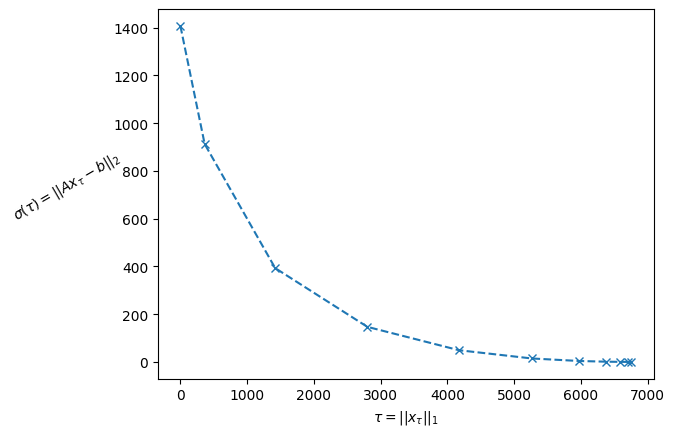

In [45]:
handel_result.plot_pareto_frontier()

## Measuring Compression
Below, we compute the sparsity for each solution $x_\tau$. The sparsity of vector $x$ defined as the fraction of entries of $x$
which are zero. The closer the sparsity is to 1, the more sparse. Instead of storing the time-domain signal, we can store the M-DCT-domain signal in a sparse matrix format. The exact storage requirements of a sparse matrix depend on storage format, and we use the compressed sparse row (CSR) format for reference, since this format is appropriate for matrix processing.

The compression ratio (CR) is the uncompressed size divided by the compressed size. We use scipy's sparse array package to empirically measure the CR. This will account for practical issues like sparse array overhead, since indices must also be used. Assuming double precision is used for the data and indices are stored in 32-bit integers, storing the indices adds an overhead of 1.5x to the sparse memory footprint. The M-DCT transform also maps $n$ data points to $2n$ coefficients, so the memory overhead is also hurt by another factor of 2.

In [46]:
from scipy import sparse as sp

In [47]:
def sparsity(x, tol=1e-4, axis=None):
    return np.sum(abs(x) < tol, axis=axis) / x.shape[axis]

In [50]:
def make_sparse(x, tol=1e-4):
    sp_x = x.copy()
    sp_x[abs(sp_x) < 1e-4] = 0
    return sp.csr_array(sp_x)

    
def csr_bytes(s):
    return s.data.nbytes + s.indices.nbytes + s.indptr.nbytes

In [51]:
x = handel_result.solutions
s = sparsity(x, axis=1, tol=1e-4)
error_power = power(np.array([Dt(x_tau) for x_tau in x]) - y, axis=1)

compressed_size = np.array([csr_bytes(make_sparse(x_i)) for x_i in x])
compression = y.nbytes / compressed_size
# This is the naive way to compute compression, that is only based on the sparsity
# of the M-DCT vector, not accounting for the previously discussed sparsity and M-DCT overhead.
# It makes the compression numbers look better, but is less realistic...
# compression = 1/(1-s)

Now, here is a table of comparing comparing $\tau$ and $\sigma$ against the more practical metrics described above.

In particular, row 6 illustrates the overhead in our representation. Even though only 37.2\% of the M-DCT coefficients are being used, the compression ratio is less than 1, indicating that the data size actually increased! Memory-wise, we'd be better just using the original dense time-domain representation.



In [52]:
from cvx_opt.hw10 import print_table

In [53]:
print_table(
    {"Tau": handel_result.tau,
     "Sparsity (%)": 100 * s,
     "Compression ratio X:1": compression,
     "% Data used": 100 * (1 - s),
     "Sigma": handel_result.sigma,
     "Quality Error (dB)": mag2db(error_power)
    }
)

            Tau  Sparsity (%)  Compression ratio X:1  % Data used  \
0      0.100000     99.999322           29245.200000     0.000678   
1    363.781210     99.675157             101.616400     0.324843   
2   1420.314940     98.037381              16.838554     1.962619   
3   2800.756622     93.353950               4.973335     6.646050   
4   4173.876571     83.669027               2.024029    16.330973   
5   5266.074142     72.018094               1.181290    27.981906   
6   5971.423479     62.792969               0.888404    37.207031   
7   6372.921866     56.951904               0.767861    43.048096   
8   6587.650214     53.826904               0.715892    46.173096   
9   6698.212522     52.058919               0.689492    47.941081   
10  6753.999529     50.851780               0.672557    49.148220   

          Sigma  Quality Error (dB)  
0   1407.234182          -28.291965  
1    912.552993          -32.054130  
2    392.846546          -39.374833  
3    146.868787    

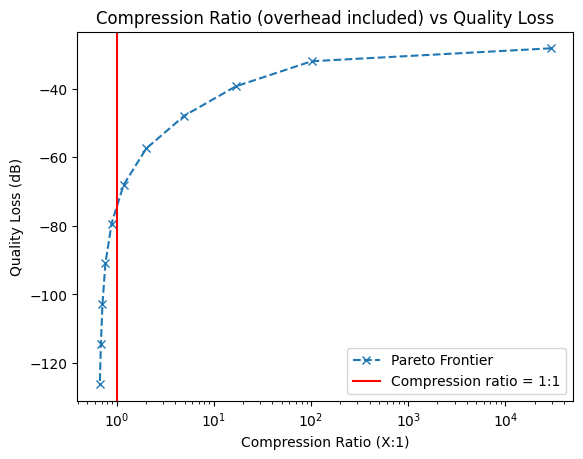

In [54]:
plt.figure()
plt.semilogx(compression, mag2db(error_power), 'x--', label="Pareto Frontier")
plt.title("Compression Ratio (overhead included) vs Quality Loss")
plt.xlabel("Compression Ratio (X:1)")
plt.ylabel("Quality Loss (dB)")
plt.axvline(x=1, c='r', label="Compression ratio = 1:1")
_ = plt.legend()


# Audio Results

For each $\tau$, we convert the sparse solution $x_{\tau}$ to an audio file.

The results are quite astonishing.

In [55]:
def get_audio(result, s, i):
    print(f"""
    Tau = {result.tau[i]:.1f}
    Sparsity = {s[i] * 100:.1f}
    Compression ratio = {compression[i]:.1f}:1
    % of data used = {(1-s[i]) * 100:.2f}
    Quality Error (dB) = {mag2db(error_power[i]):.2f}
    """)
    return Audio(Dt(result.sub_results[i].solution), rate=Fs)

The initial guess contains barely any information, and we hear exactly one note played at the 8th second, and otherwise silence.

In [56]:
result = handel_result

In [57]:
get_audio(result, s, 0)


    Tau = 0.1
    Sparsity = 100.0
    Compression ratio = 29245.2:1
    % of data used = 0.00
    Quality Error (dB) = -28.29
    


With a compression ratio of >300:1, the solution below is a highly reduced version of the original. It sounds like something from an 8-bit video game of the 1990s. However, the main melody is perserved. We can hear the Hallelujah's clearly and in tune. There are a few higher pitch overtones which is maybe indicative of the string section in the background, but none of the string instruments can heard.

In [58]:
get_audio(result, s, 1)


    Tau = 363.8
    Sparsity = 99.7
    Compression ratio = 101.6:1
    % of data used = 0.32
    Quality Error (dB) = -32.05
    


Now, using a 98\% sparse M-DCT, we start to hear more string instruments. (Note that the quality error is already better than in the previous formulation.)

In [59]:
get_audio(result, s, 2)


    Tau = 1420.3
    Sparsity = 98.0
    Compression ratio = 16.8:1
    % of data used = 1.96
    Quality Error (dB) = -39.37
    


Now, the strings are coming in quite nicely. The low notes from the cello and bass makes the music sound full and
well-rounded.

In [60]:
get_audio(result, s, 3)


    Tau = 2800.8
    Sparsity = 93.4
    Compression ratio = 5.0:1
    % of data used = 6.65
    Quality Error (dB) = -47.92
    


At ~2x compression, we can now hear harmonies in the choir. The counter-melodies of the violins and violas ring more clearly now. The sound is barely distinguishable from the original, except maybe to an audiophile.

In [61]:
get_audio(result, s, 4)


    Tau = 4173.9
    Sparsity = 83.7
    Compression ratio = 2.0:1
    % of data used = 16.33
    Quality Error (dB) = -57.46
    


Over the remaining iterations, the compression ratio shrinks as the quality error goes asymptotically towards 0.
Listening to the difference between $k=4$ and $k=10$ is interesting: one hears more depth in the timbre of the choir.

In [62]:
# try replacing 
get_audio(result, s, 10)


    Tau = 6754.0
    Sparsity = 50.9
    Compression ratio = 0.7:1
    % of data used = 49.15
    Quality Error (dB) = -126.17
    


The $k=5$ audio clip below is perhaps a happy medium between quality and compression. The quality is very good. However, despite only using ~28\% of the M-DCT coefficients, our sparse representation is only 1.2x smaller than the original.

In [63]:
get_audio(result, s, 5)


    Tau = 5266.1
    Sparsity = 72.0
    Compression ratio = 1.2:1
    % of data used = 27.98
    Quality Error (dB) = -68.05
    


# Appendix: A quick profile of the code
The code runs a bit slowly for the larger problem, especially when using a small tolerance on the proximal descent subproblem. Let's determine what is bottlenecking our operation.

In [64]:
import cProfile
from pstats import SortKey

Based on the profiling results below, the `np.sort` function called in `project_l1` to be taking a large portion of the total time. It is unlikely that the entire array needs to be sorted from scratch each time, and caching the sort order would likely speed things along...

In [290]:
def call_basis_pursuit():
    basis_pursuit(A, b, subproblem_kwargs={'tol': 1e-7}, tol_tau=1e-3, maxiters=2)

# NOTE: you will need to Keyboard interrupt this since it will take quite a while, even to go just 2 iterations at this tolerance.
cProfile.run("call_basis_pursuit()", sort=SortKey.TIME)

k = 0
k = 1
         4564966 function calls (4558607 primitive calls) in 14.100 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
     8454    7.557    0.001    7.557    0.001 {method 'sort' of 'numpy.ndarray' objects}
    12684    1.465    0.000    1.465    0.000 {built-in method scipy.fft._pocketfft.pypocketfft.dct}
     2112    1.417    0.001    9.721    0.005 hw10.py:8(project_l1)
     2112    0.667    0.000    0.667    0.000 {method 'cumsum' of 'numpy.ndarray' objects}
    59188    0.659    0.000    0.659    0.000 {method 'ravel' of 'numpy.ndarray' objects}
        2    0.243    0.121   13.559    6.780 hw6.py:426(prox_gradient_descent)
    12684    0.177    0.000    0.177    0.000 {built-in method scipy.sparse._sparsetools.csr_matvecs}
    69762    0.153    0.000    0.225    0.000 _sputils.py:264(get_index_dtype)
    12684    0.130    0.000    0.576    0.000 _dia.py:352(tocoo)
     2113    0.109    0.000   12.586    0.00

KeyboardInterrupt: 